## ============================================================
## Notebook: 04_clv_analysis.ipynb
## ============================================================

### =========================
### 1. IMPORT LIBRARIES
### =========================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

print("✅ Libraries imported")

✅ Libraries imported


### =========================
### 2. LOAD DATA
### =========================

In [2]:
df = pd.read_csv('../data/processed/cleaned_transactions.csv', parse_dates=['invoicedate'])

print(f"Loaded {len(df):,} transactions")
print(f"Unique customers: {df['customer_id'].nunique():,}")
print(f"Date range: {df['invoicedate'].min()} to {df['invoicedate'].max()}")

Loaded 779,425 transactions
Unique customers: 5,878
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


### =========================
### 3. Prepare Data for CLV Model
### =========================

In [3]:
print("\n" + "=" * 60)
print("DATA PREPARATION FOR CLV MODELING")
print("=" * 60)


data_end_date = df['invoicedate'].max()
observation_end_date = data_end_date - timedelta(days=90)  # Last 90 days for validation

print(f"Observation period end: {observation_end_date.date()}")
print(f"Holdout period: {observation_end_date.date()} to {data_end_date.date()}")

# Filter to observation period only
observation_df = df[df['invoicedate'] < observation_end_date].copy()

print(f"Observation transactions: {len(observation_df):,}")
print(f"Holdout transactions: {len(df) - len(observation_df):,}")

# Prepare data for lifetimes library
summary = summary_data_from_transaction_data(
    observation_df, 
    'customer_id', 
    'invoicedate', 
    'total_price', 
    observation_period_end=observation_end_date
)

summary.reset_index(inplace=True)
summary.columns = ['customer_id', 'frequency', 'recency', 'T', 'monetary_value']

# Filter out customers with zero or negative monetary value
summary = summary[summary['monetary_value'] > 0]
summary = summary[summary['frequency'] > 0]

print(f"\n✅ CLV dataset shape: {summary.shape}")
print(f"   Average frequency: {summary['frequency'].mean():.2f}")
print(f"   Average recency: {summary['recency'].mean():.2f} days")
print(f"   Average monetary: ${summary['monetary_value'].mean():.2f}")



DATA PREPARATION FOR CLV MODELING
Observation period end: 2011-09-10
Holdout period: 2011-09-10 to 2011-12-09
Observation transactions: 620,572
Holdout transactions: 158,853

✅ CLV dataset shape: (3626, 5)
   Average frequency: 6.03
   Average recency: 326.97 days
   Average monetary: $395.17


### ============================
### 4. Fit BG/NBD Model (Frequency/Recency)
### ============================

In [4]:
print("\n" + "=" * 60)
print("BG/NBD MODEL FITTING")
print("=" * 60)

bgf = BetaGeoFitter(penalizer_coef=0.01)  # Small penalizer to prevent overfitting
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

print("✅ BG/NBD Model Fitted")
print(f"   Model parameters:")
print(f"     r: {bgf.params_['r']:.4f}")
print(f"     alpha: {bgf.params_['alpha']:.4f}")
print(f"     a: {bgf.params_['a']:.4f}")
print(f"     b: {bgf.params_['b']:.4f}")



BG/NBD MODEL FITTING
✅ BG/NBD Model Fitted
   Model parameters:
     r: 1.4624
     alpha: 96.7835
     a: 0.1131
     b: 0.7340


### =========================
### 5. Predict Future Transactions
### =========================

In [5]:
# Predict future transactions for next 3, 6, 12 months
t_months = [3, 6, 12]

for t in t_months:
    summary[f'predicted_purchases_{t}m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
        t, summary['frequency'], summary['recency'], summary['T']
    )

print(f"\n📊 Predicted purchases next 12 months - summary:")
print(summary['predicted_purchases_12m'].describe())



📊 Predicted purchases next 12 months - summary:
count    3.626000e+03
mean     1.301909e-01
std      1.754554e-01
min      2.783481e-08
25%      4.057455e-02
50%      8.563653e-02
75%      1.596688e-01
max      3.319279e+00
Name: predicted_purchases_12m, dtype: float64


### ==============================
### 6. Fit Gamma-Gamma Model (Monetary Value)
### ==============================

In [6]:
print("\n" + "=" * 60)
print("GAMMA-GAMMA MODEL FITTING")
print("=" * 60)

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary['frequency'], summary['monetary_value'])

print("✅ Gamma-Gamma Model Fitted")
print(f"   Model parameters:")
print(f"     p: {ggf.params_['p']:.4f}")
print(f"     q: {ggf.params_['q']:.4f}")
print(f"     v: {ggf.params_['v']:.4f}")



GAMMA-GAMMA MODEL FITTING
✅ Gamma-Gamma Model Fitted
   Model parameters:
     p: 3.7875
     q: 0.3405
     v: 3.6869


### =============================
### 7. Calculate Customer Lifetime Value
### =============================

In [7]:
print("\n" + "=" * 60)
print("CLV CALCULATION")
print("=" * 60)

discount_rate = 0.01  

# Calculate CLV for different time horizons
for t in t_months:
    summary[f'clv_{t}m'] = ggf.customer_lifetime_value(
        bgf,
        summary['frequency'],
        summary['recency'],
        summary['T'],
        summary['monetary_value'],
        time=t,
        discount_rate=discount_rate
    )

print(f"📊 CLV (12 months) statistics:")
print(summary['clv_12m'].describe())
print(f"\n💰 Total predicted CLV (12 months): ${summary['clv_12m'].sum():,.2f}")



CLV CALCULATION
📊 CLV (12 months) statistics:
count      3626.000000
mean       1788.563229
std        6674.969474
min           0.000122
25%         282.194247
50%         712.880928
75%        1647.290223
max      206318.270585
Name: clv_12m, dtype: float64

💰 Total predicted CLV (12 months): $6,485,330.27


### =========================
### 8. Segment Customers by CLV
### =========================

In [8]:
# Create CLV segments using quartiles
summary['clv_segment'] = pd.qcut(summary['clv_12m'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

# Also create value tiers for business users
def get_clv_tier(clv):
    if clv < 500:
        return 'Low Value (<$500)'
    elif clv < 1500:
        return 'Medium Value ($500-$1,500)'
    elif clv < 5000:
        return 'High Value ($1,500-$5,000)'
    else:
        return 'Premium Value (>$5,000)'

summary['clv_tier'] = summary['clv_12m'].apply(get_clv_tier)

# Segment summary
clv_segment_summary = summary.groupby('clv_segment').agg({
    'customer_id': 'count',
    'clv_12m': ['mean', 'sum'],
    'frequency': 'mean',
    'monetary_value': 'mean',
    'predicted_purchases_12m': 'mean'
}).round(2)

clv_segment_summary.columns = ['count', 'avg_clv', 'total_clv', 'avg_frequency', 'avg_monetary', 'avg_predicted_purchases']
clv_segment_summary['pct_of_customers'] = (clv_segment_summary['count'] / clv_segment_summary['count'].sum() * 100).round(1)
clv_segment_summary['pct_of_value'] = (clv_segment_summary['total_clv'] / clv_segment_summary['total_clv'].sum() * 100).round(1)


In [9]:
print("\n" + "=" * 60)
print("CLV SEGMENTATION")
print("=" * 60)
print("\n📊 CLV Segmentation Summary:")
print(clv_segment_summary)


CLV SEGMENTATION

📊 CLV Segmentation Summary:
             count  avg_clv   total_clv  avg_frequency  avg_monetary  \
clv_segment                                                            
Low            907   140.70   127612.73           2.06        204.36   
Medium-Low     906   475.95   431209.60           2.88        292.60   
Medium-High    906  1102.83   999165.34           5.15        368.18   
High           907  5432.57  4927342.60          14.03        715.38   

             avg_predicted_purchases  pct_of_customers  pct_of_value  
clv_segment                                                           
Low                             0.03              25.0           2.0  
Medium-Low                      0.07              25.0           6.6  
Medium-High                     0.13              25.0          15.4  
High                            0.29              25.0          76.0  


### ===========================
### 9. Visualize 
### ===========================


GENERATING VISUALIZATIONS


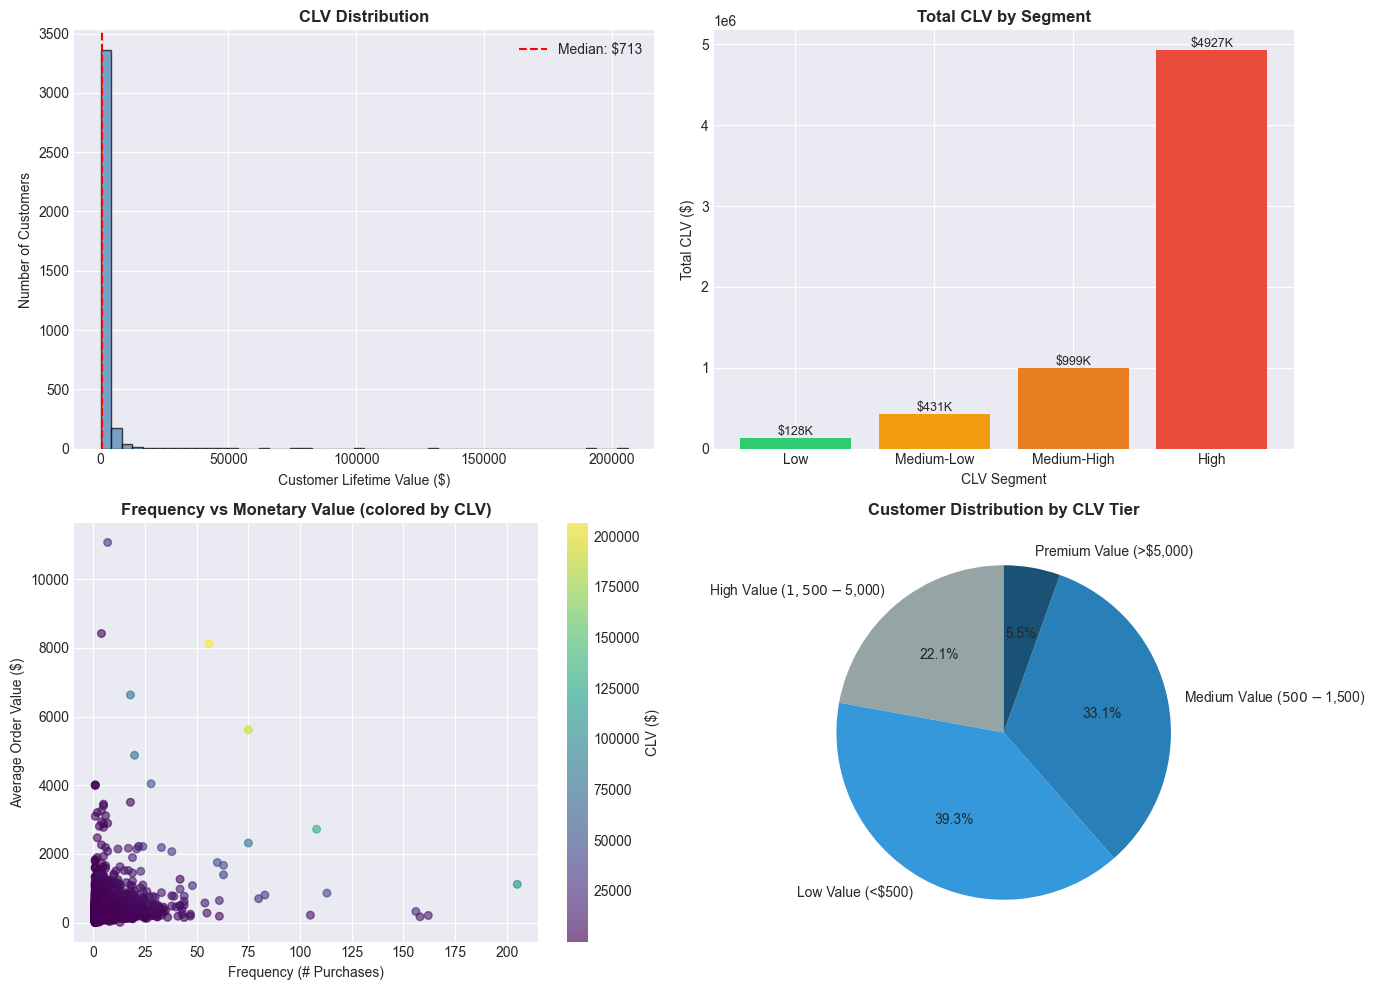

✅ Visualizations saved to '../reports/clv_analysis_visualization.png'


In [10]:
print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 9.1 CLV Distribution Histogram
axes[0, 0].hist(summary['clv_12m'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Customer Lifetime Value ($)')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].set_title('CLV Distribution', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=summary['clv_12m'].median(), color='red', linestyle='--', 
                   label=f'Median: ${summary["clv_12m"].median():,.0f}')
axes[0, 0].legend()

# 9.2 CLV by Segment Bar Chart
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[0, 1].bar(clv_segment_summary.index, clv_segment_summary['total_clv'], color=colors)
axes[0, 1].set_xlabel('CLV Segment')
axes[0, 1].set_ylabel('Total CLV ($)')
axes[0, 1].set_title('Total CLV by Segment', fontsize=12, fontweight='bold')

for bar, value in zip(bars, clv_segment_summary['total_clv']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                    f'${value/1000:.0f}K', ha='center', va='bottom', fontsize=9)

# 9.3 Frequency vs Monetary Value Scatter
sample_size = min(3000, len(summary))
sample = summary.sample(n=sample_size, random_state=42)
scatter = axes[1, 0].scatter(sample['frequency'], sample['monetary_value'], 
                              c=sample['clv_12m'], cmap='viridis', alpha=0.6, s=30)
axes[1, 0].set_xlabel('Frequency (# Purchases)')
axes[1, 0].set_ylabel('Average Order Value ($)')
axes[1, 0].set_title('Frequency vs Monetary Value (colored by CLV)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1, 0], label='CLV ($)')

# 9.4 CLV by Tier Pie Chart
tier_summary = summary.groupby('clv_tier')['customer_id'].count()
colors_tier = ['#95a5a6', '#3498db', '#2980b9', '#1a5276']
axes[1, 1].pie(tier_summary.values, labels=tier_summary.index, autopct='%1.1f%%', 
               colors=colors_tier, startangle=90)
axes[1, 1].set_title('Customer Distribution by CLV Tier', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/clv_analysis_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved to '../reports/clv_analysis_visualization.png'")



### =========================
### 10. Top Customers by CLV
### =========================

In [11]:
print("\n" + "=" * 60)
print("TOP CUSTOMERS BY PREDICTED CLV")
print("=" * 60)

top_clv = summary.nlargest(20, 'clv_12m')[[
    'customer_id', 'clv_12m', 'frequency', 'recency', 
    'monetary_value', 'predicted_purchases_12m', 'clv_segment', 'clv_tier'
]]

print(top_clv.to_string(index=False))




TOP CUSTOMERS BY PREDICTED CLV
 customer_id       clv_12m  frequency  recency  monetary_value  predicted_purchases_12m clv_segment                clv_tier
       18102 206318.270585       56.0    640.0     8115.968750                 0.921497        High Premium Value (>$5,000)
       14646 190366.720524       75.0    645.0     5613.174400                 1.230193        High Premium Value (>$5,000)
       14156 131879.529234      108.0    645.0     2720.828981                 1.759171        High Premium Value (>$5,000)
       14911 102045.595212      205.0    645.0     1116.486829                 3.319279        High Premium Value (>$5,000)
       12415  79009.887372       18.0    428.0     6628.054444                 0.433090        High Premium Value (>$5,000)
       13694  78330.717633       75.0    628.0     2319.770933                 1.224886        High Premium Value (>$5,000)
       17450  76527.312052       20.0    343.0     4872.880000                 0.573908        High 

### =================================
### 11. CREATE CLV DIMENSION TABLE 
### ================================

In [12]:
dim_customer_clv = summary[[
    'customer_id',
    'clv_12m',
    'clv_segment',
    'clv_tier',
    'predicted_purchases_12m',
    'frequency',
    'recency',
    'T',
    'monetary_value'
]].copy()

dim_customer_clv.columns = [
    'customer_id',
    'predicted_clv_12m',
    'clv_segment',
    'clv_tier',
    'expected_purchases_next_12m',
    'historical_frequency',
    'recency_days',
    'customer_age_days',
    'avg_order_value'
]

# Add CLV percentile for ranking
dim_customer_clv['clv_percentile'] = dim_customer_clv['predicted_clv_12m'].rank(pct=True) * 100

# Add CLV score 
dim_customer_clv['clv_score'] = (dim_customer_clv['clv_percentile'] / 20).round(0) * 20  # Buckets: 0,20,40,60,80,100


In [13]:
print("\n" + "=" * 60)
print("CREATING CLV DIMENSION TABLE")
print("=" * 60)

# Save dimension table
dim_customer_clv.to_csv('../data/processed/dim_customer_clv.csv', index=False)
print(f"✅ Customer CLV Dimension saved: dim_customer_clv.csv ({len(dim_customer_clv):,} rows)")



CREATING CLV DIMENSION TABLE
✅ Customer CLV Dimension saved: dim_customer_clv.csv (3,626 rows)


### ============================================
### 12. CREATE SEGMENT SUMMARY FOR DASHBOARD
### ============================================

In [14]:
# Reset index for clean export
clv_segment_summary_export = clv_segment_summary.reset_index()
clv_segment_summary_export.to_csv('../data/processed/clv_segment_summary.csv', index=False)
print(f"✅ CLV Segment Summary saved: clv_segment_summary.csv")

# Also save tier summary
tier_summary_export = summary.groupby('clv_tier').agg({
    'customer_id': 'count',
    'clv_12m': ['sum', 'mean'],
    'frequency': 'mean',
    'monetary_value': 'mean'
}).round(2)
tier_summary_export.columns = ['customer_count', 'total_clv', 'avg_clv', 'avg_frequency', 'avg_order_value']
tier_summary_export = tier_summary_export.reset_index()
tier_summary_export.to_csv('../data/processed/clv_tier_summary.csv', index=False)
print(f"✅ CLV Tier Summary saved: clv_tier_summary.csv")


✅ CLV Segment Summary saved: clv_segment_summary.csv
✅ CLV Tier Summary saved: clv_tier_summary.csv


### ================================================
### 13. VALIDATE CLV PREDICTIONS (Using Holdout Period)
### ================================================

In [15]:
print("\n" + "=" * 60)
print("MODEL VALIDATION (Holdout Period)")
print("=" * 60)

# Calculate actual purchases in holdout period
holdout_df = df[df['invoicedate'] >= observation_end_date].copy()

actual_holdout = holdout_df.groupby('customer_id').agg({
    'invoice': 'nunique',
    'total_price': 'sum'
}).reset_index()
actual_holdout.columns = ['customer_id', 'actual_purchases_holdout', 'actual_revenue_holdout']

# Merge with predictions
validation_df = summary.merge(actual_holdout, on='customer_id', how='left').fillna(0)

# Calculate prediction accuracy
from scipy.stats import pearsonr

correlation = pearsonr(validation_df['predicted_purchases_12m'], validation_df['actual_purchases_holdout'])

print(f"📊 Holdout Validation Results (90-day holdout period):")
print(f"   Correlation between predicted and actual purchases: {correlation[0]:.3f}")
print(f"   Mean Absolute Error: {(validation_df['predicted_purchases_12m'] - validation_df['actual_purchases_holdout']).abs().mean():.3f}")
print(f"   RMSE: {np.sqrt(((validation_df['predicted_purchases_12m'] - validation_df['actual_purchases_holdout'])**2).mean()):.3f}")

if correlation[0] > 0.3:
    print(f"\n✅ Model validation PASSED - Predictions are correlated with actual behavior")
else:
    print(f"\n⚠️ Model validation WARNING - Low correlation with holdout data")




MODEL VALIDATION (Holdout Period)
📊 Holdout Validation Results (90-day holdout period):
   Correlation between predicted and actual purchases: 0.783
   Mean Absolute Error: 1.325
   RMSE: 3.178

✅ Model validation PASSED - Predictions are correlated with actual behavior


### =========================
### 14. Business Recommendations
### =========================

In [16]:
print("\n" + "=" * 60)
print("BUSINESS RECOMMENDATIONS")
print("=" * 60)

# Calculate key metrics
high_value_customers = summary[summary['clv_segment'] == 'High']
medium_high_customers = summary[summary['clv_segment'] == 'Medium-High']

print(f"""
📊 CLV INSIGHTS SUMMARY:
   • Total predicted CLV (12 months): ${summary['clv_12m'].sum():,.2f}
   • High CLV segment: {len(high_value_customers):,} customers ({len(high_value_customers)/len(summary)*100:.1f}%)
   • High segment value: ${high_value_customers['clv_12m'].sum():,.2f} ({high_value_customers['clv_12m'].sum()/summary['clv_12m'].sum()*100:.1f}%)
   • Average CLV by tier:
     - Premium (>$5,000): ${summary[summary['clv_tier'] == 'Premium Value (>$5,000)']['clv_12m'].mean():,.2f}
     - High ($1,500-$5,000): ${summary[summary['clv_tier'] == 'High Value ($1,500-$5,000)']['clv_12m'].mean():,.2f}
     - Medium ($500-$1,500): ${summary[summary['clv_tier'] == 'Medium Value ($500-$1,500)']['clv_12m'].mean():,.2f}
     - Low (<$500): ${summary[summary['clv_tier'] == 'Low Value (<$500)']['clv_12m'].mean():,.2f}

🎯 RECOMMENDED ACTIONS BY SEGMENT:

   🔴 PREMIUM CUSTOMERS (Top 25% by CLV):
      • Dedicated account manager
      • Early access to new products
      • Premium loyalty program with exclusive benefits
      • Personalized thank you notes and birthday gifts

   🟠 HIGH VALUE CUSTOMERS:
      • Cross-sell and upsell campaigns
      • Product bundles based on purchase history
      • Loyalty points program with tiered rewards
      • Annual appreciation event invitations

   🟡 MEDIUM VALUE CUSTOMERS:
      • Engagement campaigns to increase purchase frequency
      • Abandoned cart recovery with small discounts
      • Product recommendation emails
      • Seasonal sale notifications

   🟢 LOW VALUE CUSTOMERS:
      • Welcome series with educational content
      • Second purchase incentive (10-15% off)
      • Customer satisfaction surveys
      • Retargeting ads for category interest

💰 FINANCIAL PROJECTIONS:
   • If we increase retention by 5% in High segment: +${high_value_customers['clv_12m'].sum() * 0.05:,.2f}
   • If we upgrade 10% of Medium-High to High: +{len(medium_high_customers) * 0.1:.0f} customers at ${medium_high_customers['clv_12m'].mean():,.2f} avg
""")



BUSINESS RECOMMENDATIONS

📊 CLV INSIGHTS SUMMARY:
   • Total predicted CLV (12 months): $6,485,330.27
   • High CLV segment: 907 customers (25.0%)
   • High segment value: $4,927,342.60 (76.0%)
   • Average CLV by tier:
     - Premium (>$5,000): $15,073.24
     - High ($1,500-$5,000): $2,603.62
     - Medium ($500-$1,500): $902.96
     - Low (<$500): $229.64

🎯 RECOMMENDED ACTIONS BY SEGMENT:

   🔴 PREMIUM CUSTOMERS (Top 25% by CLV):
      • Dedicated account manager
      • Early access to new products
      • Premium loyalty program with exclusive benefits
      • Personalized thank you notes and birthday gifts

   🟠 HIGH VALUE CUSTOMERS:
      • Cross-sell and upsell campaigns
      • Product bundles based on purchase history
      • Loyalty points program with tiered rewards
      • Annual appreciation event invitations

   🟡 MEDIUM VALUE CUSTOMERS:
      • Engagement campaigns to increase purchase frequency
      • Abandoned cart recovery with small discounts
      • Product reco

### =============================
### 15. MERGE WITH CHURN RISK 
### =============================

In [17]:
print("\n" + "=" * 60)
print("MERGING CLV WITH CHURN RISK")
print("=" * 60)

# Load churn risk data if available
try:
    churn_risk = pd.read_csv('../data/processed/dim_customer_risk.csv')
    
    # Merge CLV with churn risk
    customer_360 = dim_customer_clv.merge(churn_risk, on='customer_id', how='left')
    
    def get_strategic_segment(row):
        clv_tier = row.get('clv_tier', 'Low Value (<$500)')
        risk_level = row.get('risk_level', 'Low')
        
        if clv_tier in ['Premium Value (>$5,000)', 'High Value ($1,500-$5,000)']:
            if risk_level in ['Critical', 'High']:
                return 'CRITICAL: High-Value At Risk'
            else:
                return 'NURTURE: High-Value Loyal'
        elif clv_tier == 'Medium Value ($500-$1,500)':
            if risk_level in ['Critical', 'High']:
                return 'ACT NOW: Medium-Value At Risk'
            else:
                return 'GROW: Medium-Value Potential'
        else:
            if risk_level in ['Critical', 'High']:
                return 'MONITOR: Low-Value At Risk'
            else:
                return 'AUTOMATE: Low-Value'
    
    customer_360['strategic_segment'] = customer_360.apply(get_strategic_segment, axis=1)
    
    # Save customer 360 view
    customer_360.to_csv('../data/processed/customer_360_view.csv', index=False)
    print(f"✅ Customer 360 view saved: customer_360_view.csv ({len(customer_360):,} rows)")
    
    # Strategic segment summary
    strategic_summary = customer_360.groupby('strategic_segment').agg({
        'customer_id': 'count',
        'predicted_clv_12m': 'sum'
    }).round(2).sort_values('predicted_clv_12m', ascending=False)
    strategic_summary.columns = ['customer_count', 'total_clv']
    
    print(f"\n📊 STRATEGIC SEGMENT SUMMARY (CLV + Churn Risk):")
    print(strategic_summary.to_string())
    
except FileNotFoundError:
    print("⚠️ Churn risk data not found. Run churn prediction notebook first for 360 view.")




MERGING CLV WITH CHURN RISK
✅ Customer 360 view saved: customer_360_view.csv (3,626 rows)

📊 STRATEGIC SEGMENT SUMMARY (CLV + Churn Risk):
                               customer_count   total_clv
strategic_segment                                        
NURTURE: High-Value Loyal                 988  5014674.00
GROW: Medium-Value Potential             1097  1010124.66
AUTOMATE: Low-Value                       705   203001.00
MONITOR: Low-Value At Risk                721   124468.81
ACT NOW: Medium-Value At Risk             102    72526.69
CRITICAL: High-Value At Risk               13    60535.11


### ===================================
### 16. EXPORT FOR POWER BI DASHBOARD
### ===================================

In [18]:
print("\n" + "=" * 60)
print("EXPORTING FOR POWER BI")
print("=" * 60)

# All exports are already saved above. Summary of files:
exported_files = [
    'dim_customer_clv.csv',
    'clv_segment_summary.csv',
    'clv_tier_summary.csv',
    'customer_360_view.csv'
]

print("📁 Exported Files for Power BI:")
print("   ┌────────────────────────────────────────────────────────────┐")
for f in exported_files:
    print(f"   │ {f:<55} │")
print("   └────────────────────────────────────────────────────────────┘")



EXPORTING FOR POWER BI
📁 Exported Files for Power BI:
   ┌────────────────────────────────────────────────────────────┐
   │ dim_customer_clv.csv                                    │
   │ clv_segment_summary.csv                                 │
   │ clv_tier_summary.csv                                    │
   │ customer_360_view.csv                                   │
   └────────────────────────────────────────────────────────────┘


### ========================
### 17. FINAL SUMMARY
### ========================

In [19]:
print("\n" + "=" * 60)
print("🎉 CLV ANALYSIS COMPLETE!")
print("=" * 60)

print(f"""
✅ MODEL PERFORMANCE SUMMARY:
   • BG/NBD + Gamma-Gamma models fitted successfully
   • Predicted CLV for {len(summary):,} customers
   • Total predicted value: ${summary['clv_12m'].sum():,.2f}
   • Holdout validation correlation: {correlation[0]:.3f}

📁 POWER BI READY FILES:
   • dim_customer_clv.csv - Customer CLV dimension
   • clv_segment_summary.csv - Segment-level aggregates
   • clv_tier_summary.csv - Tier-level aggregates
   • customer_360_view.csv - Combined CLV + Churn Risk view

🎯 NEXT STEPS:
   1. Load these tables into Power BI
   2. Create relationships with existing fact_transactions table
   3. Build CLV dashboard showing:
      - Customer lifetime value distribution
      - CLV by acquisition cohort
      - CLV by customer segment
      - Strategic action matrix (CLV vs Churn Risk)
""")


🎉 CLV ANALYSIS COMPLETE!

✅ MODEL PERFORMANCE SUMMARY:
   • BG/NBD + Gamma-Gamma models fitted successfully
   • Predicted CLV for 3,626 customers
   • Total predicted value: $6,485,330.27
   • Holdout validation correlation: 0.783

📁 POWER BI READY FILES:
   • dim_customer_clv.csv - Customer CLV dimension
   • clv_segment_summary.csv - Segment-level aggregates
   • clv_tier_summary.csv - Tier-level aggregates
   • customer_360_view.csv - Combined CLV + Churn Risk view

🎯 NEXT STEPS:
   1. Load these tables into Power BI
   2. Create relationships with existing fact_transactions table
   3. Build CLV dashboard showing:
      - Customer lifetime value distribution
      - CLV by acquisition cohort
      - CLV by customer segment
      - Strategic action matrix (CLV vs Churn Risk)

